# How much capacity does the fee-growth signal actually have?

Fourth and last notebook. Notebook 3 established two things:

* The signal is **zero** in perp-listed (liquid) names — t +0.04 design,
  -0.19 holdout.
* It is **present** in non-perp (illiquid) names — t +1.22 design, +1.92
  holdout, the only result that survived out of sample.

That made it look like a liquidity premium. But every backtest in the sequence
charged a **flat 100bp round trip**, which for tokens with no perp listing was
always the weakest assumption in the work. If the effect only exists in names
too illiquid to short, the obvious question is whether it is also too illiquid
to *trade* — and a flat cost cannot answer that.

This notebook replaces the flat assumption with measured order-book depth and
asks one question: **at what size does the edge disappear?**

There is no tuning here and no holdout to protect. The strategy is fixed — it
is the one notebook 3 arrived at. Only the cost model changes.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = REPO / "data" / "crypto_panel"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


BACKTEST_START = pd.Timestamp("2021-06-01")
DESIGN_END = pd.Timestamp("2025-03-01")
MIN_FEES_90D, MIN_PRICE_DAYS = 1e6, 180
N_QUINTILES, REBAL_D, COST_BPS = 5, 30, 100.0

## 1. Panel

Same data as notebook 2, rebuilt by `experiments/build_crypto_panel.py` and
committed. The loading and cleaning block below is deliberately duplicated
rather than imported, so this notebook stands alone.

In [2]:
PX_RAW = pd.read_csv(PANEL / "prices.csv.gz", index_col=0, parse_dates=True)
FEES = pd.read_csv(PANEL / "fees.csv.gz", index_col=0, parse_dates=True)
BENCH = pd.read_csv(PANEL / "benchmarks.csv.gz", index_col=0, parse_dates=True)

CAL = pd.date_range(PX_RAW.index.min(), PX_RAW.index.max(), freq="D")
PX_RAW, FEES = PX_RAW.reindex(CAL), FEES.reindex(CAL).fillna(0.0)

lp = np.log(PX_RAW.where(PX_RAW > 0))
d1, d2 = lp.diff(), lp.diff().shift(-1)
bad = (d1.abs() > 1.5) & (d2.abs() > 1.5) & (np.sign(d1) != np.sign(d2))
PX = PX_RAW.where(PX_RAW > 0).mask(bad)
PX = PX.where(~bad, np.exp((np.log(PX).ffill() + np.log(PX).bfill()) / 2))
was_missing = PX.isna()
PX = PX.ffill(limit=3).where(PX.bfill().notna())
FILLED = was_missing & PX.notna()

first_fee = FEES.where(FEES > 0).apply(lambda c: c.first_valid_index())
for c in PX.columns:
    ff = first_fee.get(c)
    if pd.notna(ff):
        PX.loc[: ff - pd.Timedelta(days=365), c] = np.nan

RET = PX.pct_change()
RET_TRUE = RET.mask(FILLED | FILLED.shift(-1, fill_value=False) | PX.isna())
BTC = BENCH["bitcoin"].dropna()
btc_ret = BTC.reindex(CAL).ffill().pct_change()

FEES_90 = FEES.rolling(90, min_periods=60).sum()
HAS_HIST = PX.notna().rolling(MIN_PRICE_DAYS, min_periods=MIN_PRICE_DAYS).count() >= MIN_PRICE_DAYS
ELIGIBLE = (FEES_90 >= MIN_FEES_90D) & HAS_HIST & PX.notna()
VOL = RET_TRUE.rolling(60, min_periods=40).std()
BETA_BTC = (RET_TRUE.rolling(90, min_periods=60).cov(btc_ret)
            .div(btc_ret.rolling(90, min_periods=60).var(), axis=0))

w = ELIGIBLE.div(ELIGIBLE.sum(axis=1).replace(0, np.nan), axis=0)
reb = pd.Series(False, index=w.index); reb.iloc[::REBAL_D] = True
BASKET_RET = (RET * w.where(reb).ffill().shift(1)).sum(axis=1, min_count=1)
BASKET = (1 + BASKET_RET.fillna(0)).cumprod()[ELIGIBLE.sum(axis=1) >= 15]

print(f"panel {PX.shape}  {CAL[0].date()} -> {CAL[-1].date()}")
print(f"design  {BACKTEST_START.date()} -> {DESIGN_END.date()}")
print(f"holdout {DESIGN_END.date()} -> {CAL[-1].date()}   (untouched until the last section)")

panel (2807, 200)  2019-01-01 -> 2026-09-07
design  2021-06-01 -> 2025-03-01
holdout 2025-03-01 -> 2026-09-07   (untouched until the last section)


## 2. Shortable universe (carried over from notebook 3)

Notebook 2 could not answer this. It needed perpetual-futures listings per
token, with **listing dates**, so shortability can be applied point-in-time
rather than assuming today's venue coverage existed in 2021.

Two free sources, fetched by `experiments/fetch_perp_listings.py`:

* **OKX** — `/api/v5/public/instruments?instType=SWAP` publishes `listTime` per
  instrument. Spot-checked and sane: BTC 2019-11, LDO 2023-02, HYPE 2025-02.
* **Hyperliquid** — no listing field, so the date is taken as the timestamp of
  the coin's earliest funding record, which is when the perp began trading.

(Binance would have been the deepest source but its API refuses requests from
this host on geographic grounds, and Bybit's CDN does the same. OKX plus
Hyperliquid is what a researcher in this environment can actually reach.)

In [3]:
perp = pd.read_csv(PANEL / "perp_listings.csv")
perp["perp_listed"] = pd.to_datetime(perp["perp_listed"])
listed = perp.set_index("gecko_id")["perp_listed"]

SHORTABLE = pd.DataFrame(False, index=CAL, columns=PX.columns)
for c in PX.columns:
    d = listed.get(c)
    if pd.notna(d):
        SHORTABLE.loc[d:, c] = True
SHORTABLE = SHORTABLE & ELIGIBLE
UNSHORT = ELIGIBLE & ~SHORTABLE

top40 = perp.nlargest(40, "alltime_fees")
share = (SHORTABLE.sum(axis=1) / ELIGIBLE.sum(axis=1).replace(0, np.nan)).loc[BACKTEST_START:]
print("SHORTABILITY\n")
print(f"  tokens with a live perp (OKX or Hyperliquid) : {int(listed.notna().sum())}/{len(listed)}")
print(f"  among the 40 largest by lifetime fees        : {int(top40.perp_listed.notna().sum())}/40")
print(f"  mean share of the eligible cross-section     : {share.mean()*100:.0f}%")
print(f"  earliest listing {listed.min().date()}, median {listed.median().date()}\n")
cmp = pd.DataFrame({"eligible": ELIGIBLE.sum(axis=1), "shortable": SHORTABLE.sum(axis=1)})
cmp["shortable_%"] = cmp.shortable / cmp.eligible.replace(0, np.nan) * 100
print(cmp.loc[BACKTEST_START:].resample("YE").mean().round(1).to_string())
print("\n  Answer: YES, the short leg exists. 34 of the 40 biggest fee earners have")
print("  a perp, and ~44% of the eligible cross-section is shortable on a given day.")

SHORTABILITY

  tokens with a live perp (OKX or Hyperliquid) : 86/200
  among the 40 largest by lifetime fees        : 34/40
  mean share of the eligible cross-section     : 44%
  earliest listing 2019-11-12, median 2024-01-05

            eligible  shortable  shortable_%
2021-12-31    28.800     13.100       45.900
2022-12-31    39.200     16.200       41.400
2023-12-31    50.000     21.200       42.400
2024-12-31    91.400     38.200       42.000
2025-12-31   123.000     50.500       41.000
2026-12-31    98.900     51.400       52.300

  Answer: YES, the short leg exists. 34 of the 40 biggest fee earners have
  a perp, and ~44% of the eligible cross-section is shortable on a given day.


## 3. Engine

One backtester. Long the cheap quintile of everything eligible; short the
expensive quintile **of only what could be shorted on that date**. Costs on
realised turnover, forward returns winsorised at 1%/99% cross-sectionally.

In [4]:
def rebalance_dates(start, horizon, offset=0):
    return CAL[CAL >= start][offset::horizon]


def zs(df):
    """Cross-sectional rank -> z. Ranking first stops one outlier setting the
    scale; crypto fee growth has an extremely fat right tail."""
    return (df.where(ELIGIBLE).rank(axis=1, pct=True) - 0.5) * np.sqrt(12)


def run(signal, horizon=REBAL_D, n_q=N_QUINTILES, vol_wt=False, beta_neutral=False,
        shortable=None, universe=None, start=BACKTEST_START, end=DESIGN_END,
        offset=0, cost_bps=COST_BPS, winsor=0.01, long_only=False):
    elig = ELIGIBLE if universe is None else universe
    sh = elig if shortable is None else (shortable & elig)
    dates = rebalance_dates(start, horizon, offset)
    dates = dates[dates < end] if end is not None else dates
    fwd = PX.shift(-horizon) / PX - 1.0
    sig, fwe = signal.where(elig), fwd.where(elig)

    recs, Ws = [], []
    for d in dates:
        s = sig.loc[d].replace([np.inf, -np.inf], np.nan).dropna()
        r = fwe.loc[d].dropna()
        both = s.index.intersection(r.index)
        if len(both) < n_q * 3:
            continue
        s, r = s[both], r[both]
        r = r.clip(r.quantile(winsor), r.quantile(1 - winsor))

        n_long = max(2, len(s) // n_q)
        longs = s.nsmallest(n_long).index
        w = pd.Series(0.0, index=both)
        w[longs] = 1.0 / n_long

        if not long_only:
            s_short = s[both.intersection(sh.loc[d][sh.loc[d]].index)]
            if len(s_short) < 4:
                continue
            n_short = max(2, len(s_short) // n_q)
            w[s_short.nlargest(n_short).index] = -1.0 / n_short
            if vol_wt:
                iv = (1.0 / VOL.loc[d].reindex(both)).replace([np.inf, -np.inf], np.nan)
                iv = iv.fillna(iv.median())
                for side in (w > 0, w < 0):
                    if side.sum():
                        w[side] = np.sign(w[side]) * iv[side] / iv[side].sum()
            if beta_neutral:
                b = BETA_BTC.loc[d].reindex(both).fillna(1.0).clip(0.1, 3.0)
                bl, bs = (w[w > 0] * b[w > 0]).sum(), -(w[w < 0] * b[w < 0]).sum()
                if bs > 0.05:
                    w[w < 0] *= bl / bs
        recs.append({"date": d, "ret": float((w * r).sum()), "bench": float(r.mean()),
                     "n_long": len(longs), "n_short": int((w < 0).sum())})
        Ws.append(w)

    if len(recs) < 6:
        return None
    df = pd.DataFrame(recs).set_index("date")
    W = pd.DataFrame(Ws, index=df.index).fillna(0.0)
    turn = float(W.diff().abs().sum(axis=1).fillna(W.abs().sum(axis=1)).mean())
    gross = df["ret"] - df["bench"] if long_only else df["ret"]
    net = gross - turn * (cost_bps / 2) / 1e4
    return {"n": len(net), "net_%": net.mean() * 100,
            "t_net": net.mean() / (net.std(ddof=1) / np.sqrt(len(net))),
            "sharpe": net.mean() / net.std(ddof=1) * np.sqrt(365 / horizon),
            "turnover": turn, "n_long": df.n_long.mean(), "n_short": df.n_short.mean(),
            "series": net, "bench_%": df["bench"].mean() * 100}


def row(r, **extra):
    return {**extra, **{k: v for k, v in r.items() if k != "series"}} if r else None


# Signals: notebook 2's raw definitions, plus lookback variants and a composite.
def fee_growth_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return f / f.shift(lb) - 1


def value_gap_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return (PX / PX.shift(lb) - 1) - (f / f.shift(lb) - 1)


RAW_VALUE_GAP = value_gap_lb(90)
RAW_FEE_GROWTH = fee_growth_lb(90)
SIGS = {}
for lb in (30, 60, 90, 180):
    SIGS[f"fee_growth_{lb}d"] = -zs(fee_growth_lb(lb))   # long high growth
    SIGS[f"value_gap_{lb}d"] = zs(value_gap_lb(lb))      # long cheap
SIGS["composite"] = (SIGS["value_gap_90d"] + SIGS["fee_growth_90d"]) / 2
print(f"{len(SIGS)} signal variants defined")

9 signal variants defined


In [5]:
# Signals: notebook 2's raw definitions, plus lookback variants and a composite.
def fee_growth_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return f / f.shift(lb) - 1


def value_gap_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return (PX / PX.shift(lb) - 1) - (f / f.shift(lb) - 1)


RAW_VALUE_GAP = value_gap_lb(90)
RAW_FEE_GROWTH = fee_growth_lb(90)
SIGS = {}
for lb in (30, 60, 90, 180):
    SIGS[f"fee_growth_{lb}d"] = -zs(fee_growth_lb(lb))   # long high growth
    SIGS[f"value_gap_{lb}d"] = zs(value_gap_lb(lb))      # long cheap
SIGS["composite"] = (SIGS["value_gap_90d"] + SIGS["fee_growth_90d"]) / 2
print(f"{len(SIGS)} signal variants defined")

9 signal variants defined


## 4. Liquidity data

`experiments/fetch_liquidity.py` pulls CoinGecko's `/coins/{id}/tickers?depth=true`
for every token the non-perp book actually holds. Per venue it returns:

* **`cost_to_move_up_usd` / `cost_to_move_down_usd`** — the USD notional needed
  to move the price 2%. This is order-book depth, not volume, and it is what a
  capacity study actually needs.
* **`bid_ask_spread_percentage`** and **`converted_volume.usd`**.
* **`is_anomaly`** and **`is_stale`** quality flags.

One thing to flag rather than paper over: CoinGecko's `trust_score` — its own
wash-trading rating — comes back **null on every one of the ~1,200 venue rows**
on the free tier. So venue quality here is filtered only on `is_anomaly` and
`is_stale`, which are populated, and the wash-trading question is answered
below with the depth-to-volume ratio instead, which is the harder evidence
anyway.

Depth is **summed across every quoting venue**, which assumes a trader can
sweep all of them at once. That is generous. Every capacity number below is
therefore an upper bound.

In [6]:
LIQ = pd.read_csv(PANEL / "liquidity.csv")
ok = LIQ[LIQ.depth_2pct_usd.notna() & (LIQ.depth_2pct_usd > 0)].set_index("gecko_id")
print(f"liquidity fetched for {len(LIQ)} tokens; usable depth for {len(ok)}")
print(f"  median venues per token: {ok.n_venues.median():.0f}, of which "
      f"{ok.n_quoting.median():.0f} publish depth")
print(f"  share of reported volume on anomalous or stale venues: median "
      f"{ok.flagged_vol_share.median()*100:.0f}%, mean {ok.flagged_vol_share.mean()*100:.0f}%")

print(f"\n2% market depth, USD, across the {len(ok)} names in the book:")
for k, v in ok.depth_2pct_usd.quantile([.1, .25, .5, .75, .9]).items():
    print(f"    {int(k*100):>3d}th pct  ${v:>13,.0f}")
print(f"    mean       ${ok.depth_2pct_usd.mean():>13,.0f}")
print(f"\nspread (volume-weighted): median {ok.spread_pct.median():.2f}%  "
      f"75th {ok.spread_pct.quantile(.75):.2f}%  90th {ok.spread_pct.quantile(.9):.2f}%")

liquidity fetched for 117 tokens; usable depth for 100
  median venues per token: 22, of which 19 publish depth
  share of reported volume on anomalous or stale venues: median 3%, mean 11%

2% market depth, USD, across the 100 names in the book:
     10th pct  $        1,173
     25th pct  $        9,606
     50th pct  $       94,383
     75th pct  $      977,399
     90th pct  $    4,707,867
    mean       $    3,208,461

spread (volume-weighted): median 0.47%  75th 0.64%  90th 1.18%


### 4.1 Reported volume is not liquidity

The single most misleading number in crypto is 24h volume. Depth is the honest
one, and the ratio between them is the reason a flat cost assumption fails.

In [7]:
wash = ok[ok.adv_usd_quoting > 0].copy()
wash["depth_per_vol"] = wash.depth_2pct_usd / wash.adv_usd_quoting
print(f"2% depth as a share of the same venues' 24h volume:")
for k, v in wash.depth_per_vol.quantile([.1, .25, .5, .75, .9]).items():
    print(f"    {int(k*100):>3d}th pct  {v*100:>6.2f}%")
print(f"\n  median token: ${wash.adv_usd_quoting.median():,.0f} of reported daily volume, "
      f"${wash.depth_2pct_usd.median():,.0f} of depth within 2% of mid")
print("""
  A name reporting eight figures of daily volume routinely has five figures of
  depth. Sizing a book off volume instead of depth would overstate capacity by
  one to two orders of magnitude - which is exactly the error a flat 100bp
  assumption makes on your behalf.""")

2% depth as a share of the same venues' 24h volume:
     10th pct    2.96%
     25th pct    6.63%
     50th pct   19.26%
     75th pct   79.78%
     90th pct  307.54%

  median token: $676,222 of reported daily volume, $94,383 of depth within 2% of mid

  A name reporting eight figures of daily volume routinely has five figures of
  depth. Sizing a book off volume instead of depth would overstate capacity by
  one to two orders of magnitude - which is exactly the error a flat 100bp
  assumption makes on your behalf.


## 5. Impact model

For a clip of `Q` dollars in a token with 2% depth `D` and spread `s`:

$$\text{one-way cost} = \frac{s}{2} + 2\% \times \sqrt{Q/D}$$

The square root is the standard empirical form for market impact. The
calibration is anchored on the measured data rather than assumed: at `Q = D`
the impact term returns exactly the 2% that CoinGecko's depth figure is
defined as. At a tenth of depth it gives 63bp, at a hundredth 20bp.

A rebalance trades `|Δw|` of each name, so cost charged per period is
`Σ |Δw_i| × one-way cost(Q_i)`. Entry and exit are each captured when they
happen, so nothing is double counted.

In [8]:
def impact_bps(clip_usd, depth_usd, spread_pct):
    """One-way cost in bps for a clip of `clip_usd` against 2%-depth `depth_usd`."""
    half_spread = np.where(np.isfinite(spread_pct), spread_pct, 1.0) / 2 * 100
    imp = 200.0 * np.sqrt(np.clip(clip_usd, 0, None) / np.maximum(depth_usd, 1.0))
    return half_spread + imp


print("one-way cost, worked examples:")
for clip, dep in ((10_000, 100_000), (50_000, 100_000), (100_000, 100_000),
                  (10_000, 20_000), (100_000, 1_000_000)):
    print(f"  clip ${clip:>8,.0f} against ${dep:>9,.0f} of depth -> "
          f"{impact_bps(clip, dep, 0.5):>7.0f}bp")

one-way cost, worked examples:
  clip $  10,000 against $  100,000 of depth ->      88bp
  clip $  50,000 against $  100,000 of depth ->     166bp
  clip $ 100,000 against $  100,000 of depth ->     225bp
  clip $  10,000 against $   20,000 of depth ->     166bp
  clip $ 100,000 against $1,000,000 of depth ->      88bp


## 6. The book, and what it costs to run at size

The portfolio under test is the one notebook 3 found: the composite fee-growth
signal, sorted and traded **entirely within the non-perp universe**, long the
cheap quintile and short the expensive one. That is the only version that
survived out of sample, and it is the only one worth costing.

Weights are rebuilt explicitly so the same matrix drives both the return and
the cost, name by name.

In [9]:
def build_book(signal, universe, horizon=REBAL_D, n_q=N_QUINTILES,
               start=BACKTEST_START, end=None, winsor=0.01):
    dates = rebalance_dates(start, horizon)
    dates = dates[dates < end] if end is not None else dates
    fwd = PX.shift(-horizon) / PX - 1.0
    sig, fwe = signal.where(universe), fwd.where(universe)
    W, R = {}, {}
    for d in dates:
        s = sig.loc[d].replace([np.inf, -np.inf], np.nan).dropna()
        r = fwe.loc[d].dropna()
        both = s.index.intersection(r.index)
        if len(both) < n_q * 3:
            continue
        s, r = s[both], r[both]
        r = r.clip(r.quantile(winsor), r.quantile(1 - winsor))
        n = max(2, len(s) // n_q)
        w = pd.Series(0.0, index=both)
        w[s.nsmallest(n).index] = 1.0 / n
        w[s.nlargest(n).index] = -1.0 / n
        W[d], R[d] = w, float((w * r).sum())
    W = pd.DataFrame(W).T.fillna(0.0)
    return W, pd.Series(R)


W_ALL, GROSS = build_book(SIGS["composite"], UNSHORT)
TRADE = W_ALL.diff().abs().fillna(W_ALL.abs())
print(f"book: {len(W_ALL)} rebalances, {W_ALL.shape[1]} tokens, "
      f"{(W_ALL != 0).sum(axis=1).mean():.1f} positions per rebalance")
print("""
  Note on reconciling with notebook 3: this book rebalances on one continuous
  30-day cycle running from 2021, and the holdout is simply the tail of it.
  Notebook 3 restarted the rebalance clock at the split date, which lands on
  different days and gives a slightly different holdout number (+6.2% there vs
  the gross figure below). The continuous cycle is the honest one - a live book
  does not reset its calendar - and notebook 3's own timing-luck analysis is why
  the difference is unsurprising.""")
print(f"gross spread: {GROSS.mean()*100:+.2f}%/30d over the whole period")
print(f"turnover: {TRADE.sum(axis=1).mean():.2f} of gross exposure per rebalance")

# Depth and spread per name. Some held tokens have no usable quote at all -
# typically because they have since been delisted everywhere. What we assume
# about them matters, so it is a parameter with a sensitivity rather than a
# silent choice. Baseline is the median of the names we DO have.
def depth_vector(missing_assumption="median"):
    fill = {"median": ok.depth_2pct_usd.median(),
            "pessimistic": ok.depth_2pct_usd.quantile(0.10),
            "generous": ok.depth_2pct_usd.quantile(0.90)}[missing_assumption]
    d = pd.Series(float(fill), index=W_ALL.columns)
    d.update(ok.depth_2pct_usd)
    return d


DEPTH = depth_vector("median")
SPREAD = pd.Series(float(ok.spread_pct.median()), index=W_ALL.columns)
SPREAD.update(ok.spread_pct.fillna(ok.spread_pct.median()))
held_names = W_ALL.columns[(W_ALL != 0).any()]
missing = [c for c in held_names if c not in ok.index]
miss_wt = TRADE[missing].sum().sum() / TRADE.sum().sum() if missing else 0.0
print(f"\nnames held: {len(held_names)}; with a usable depth quote: {len(held_names)-len(missing)}")
print(f"  the {len(missing)} without one carry {miss_wt*100:.1f}% of all trading; "
      f"baseline assumes median depth (${ok.depth_2pct_usd.median():,.0f}) for them")


def net_at_aum(aum, W=W_ALL, gross=GROSS, trade=TRADE, depth=None):
    depth = DEPTH if depth is None else depth
    clip = trade * aum
    cost_rate = pd.DataFrame(
        impact_bps(clip.to_numpy(), depth.reindex(W.columns).to_numpy()[None, :],
                   SPREAD.reindex(W.columns).to_numpy()[None, :]) / 1e4,
        index=W.index, columns=W.columns)
    cost = (trade * cost_rate).sum(axis=1)
    return gross - cost, cost

book: 58 rebalances, 127 tokens, 15.6 positions per rebalance

  Note on reconciling with notebook 3: this book rebalances on one continuous
  30-day cycle running from 2021, and the holdout is simply the tail of it.
  Notebook 3 restarted the rebalance clock at the split date, which lands on
  different days and gives a slightly different holdout number (+6.2% there vs
  the gross figure below). The continuous cycle is the honest one - a live book
  does not reset its calendar - and notebook 3's own timing-luck analysis is why
  the difference is unsurprising.
gross spread: +5.68%/30d over the whole period
turnover: 1.97 of gross exposure per rebalance

names held: 125; with a usable depth quote: 100
  the 25 without one carry 13.3% of all trading; baseline assumes median depth ($94,383) for them


### 6.1 Capacity

Costs are priced off a **current** liquidity snapshot. That is defensible for
the holdout (2025-03 to 2026-09, ending today) and optimistic-to-meaningless
for the design period, where many of these names have since fallen 95-99% and
were far more liquid at the time than they are now. **The holdout column is the
one to read**; the design column is shown only to make the distortion visible.

In [10]:
rows = []
for aum in (25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000, 2_500_000, 10_000_000):
    net, cost = net_at_aum(aum)
    for lbl, mask in (("design", net.index < DESIGN_END), ("holdout", net.index >= DESIGN_END)):
        n = net[mask]
        if len(n) < 6:
            continue
        rows.append({"AUM_usd": aum, "period": lbl, "n": len(n),
                     "cost_bps": cost[mask].mean() * 1e4,
                     "gross_%": GROSS[mask].mean() * 100, "net_%": n.mean() * 100,
                     "t_net": n.mean() / (n.std(ddof=1) / np.sqrt(len(n))),
                     "sharpe": n.mean() / n.std(ddof=1) * np.sqrt(365 / REBAL_D)})
CAP = pd.DataFrame(rows)
print("CAPACITY — cost priced off real order-book depth\n")
print(CAP.pivot(index="AUM_usd", columns="period",
                values=["cost_bps", "net_%", "t_net"]).round(2).to_string())

hold = CAP[CAP.period == "holdout"].set_index("AUM_usd")
pos = hold[hold.net_ > 0] if "net_" in hold else hold[hold["net_%"] > 0]
print(f"\n  holdout gross edge: {hold['gross_%'].iloc[0]:+.2f}%/30d")
if len(pos):
    print(f"  net-positive up to AUM ${pos.index.max():,.0f}  "
          f"(net {pos['net_%'].iloc[-1]:+.2f}%/30d, t={pos['t_net'].iloc[-1]:.2f})")
else:
    print("  net-negative at every AUM tested, including the smallest")
print(f"  the flat 100bp assumed in notebooks 2-3 corresponds to roughly "
      f"${np.interp(100, hold['cost_bps'], hold.index):,.0f} of AUM here")

CAPACITY — cost priced off real order-book depth

          cost_bps             net_%          t_net        
period      design   holdout  design holdout design holdout
AUM_usd                                                    
25000      417.500   184.950   2.030   2.660  0.470   1.360
50000      560.900   235.520   0.600   2.160  0.140   1.100
100000     763.700   307.020  -1.430   1.440 -0.330   0.730
250000   1,166.080   448.900  -5.450   0.020 -1.230   0.010
500000   1,619.560   608.780  -9.990  -1.580 -2.160  -0.760
1000000  2,260.870   834.900 -16.400  -3.840 -3.290  -1.760
2500000  3,533.310 1,283.550 -29.120  -8.320 -4.920  -3.430
10000000 6,995.320 2,504.210 -63.740 -20.530 -6.810  -6.160

  holdout gross edge: +4.51%/30d
  net-positive up to AUM $250,000  (net +0.02%/30d, t=0.01)
  the flat 100bp assumed in notebooks 2-3 corresponds to roughly $25,000 of AUM here


In [11]:
print("\nSENSITIVITY — what we assume about names with no depth quote\n")
srows = []
for assumption in ("pessimistic", "median", "generous"):
    d = depth_vector(assumption)
    for aum in (25_000, 100_000, 250_000, 1_000_000):
        net, cost = net_at_aum(aum, depth=d)
        m = net.index >= DESIGN_END
        srows.append({"missing_names_assumed": assumption, "AUM_usd": aum,
                      "cost_bps": cost[m].mean() * 1e4, "net_%_holdout": net[m].mean() * 100})
S = pd.DataFrame(srows)
print(S.pivot(index="AUM_usd", columns="missing_names_assumed",
              values=["cost_bps", "net_%_holdout"]).round(1).to_string())
print("""
  The capacity conclusion does not turn on this assumption: even the generous
  case is under water well before seven figures.""")


SENSITIVITY — what we assume about names with no depth quote

                      cost_bps                     net_%_holdout                   
missing_names_assumed generous  median pessimistic      generous median pessimistic
AUM_usd                                                                            
25000                  178.500 185.000     245.200         2.700  2.700       2.100
100000                 294.100 307.000     427.400         1.600  1.400       0.200
250000                 428.400 448.900     639.300         0.200  0.000      -1.900
1000000                793.900 834.900   1,215.700        -3.400 -3.800      -7.600

  The capacity conclusion does not turn on this assumption: even the generous
  case is under water well before seven figures.


In [12]:
print("\nSENSITIVITY — the shape of the impact curve\n")
print("""  The square-root law is the standard empirical form, but it is a choice. A
  linear model (impact = 2% x Q/D) is gentler on small clips and harsher on large
  ones, so it brackets the answer from the other side.\n""")


def net_linear(aum):
    clip = TRADE * aum
    d = DEPTH.reindex(W_ALL.columns).to_numpy()[None, :]
    sp = SPREAD.reindex(W_ALL.columns).to_numpy()[None, :]
    rate = (np.where(np.isfinite(sp), sp, 1.0) / 2 * 100
            + 200.0 * (clip.to_numpy() / np.maximum(d, 1.0))) / 1e4
    cost = (TRADE * pd.DataFrame(rate, index=W_ALL.index, columns=W_ALL.columns)).sum(axis=1)
    return GROSS - cost, cost


frows = []
for aum in (25_000, 50_000, 100_000, 250_000, 1_000_000):
    for lbl, fn in (("sqrt (baseline)", net_at_aum), ("linear", net_linear)):
        net, cost = fn(aum)
        m = net.index >= DESIGN_END
        frows.append({"impact_model": lbl, "AUM_usd": aum,
                      "cost_bps": cost[m].mean() * 1e4, "net_%_holdout": net[m].mean() * 100})
F = pd.DataFrame(frows)
print(F.pivot(index="AUM_usd", columns="impact_model",
              values=["cost_bps", "net_%_holdout"]).round(1).to_string())


SENSITIVITY — the shape of the impact curve

  The square-root law is the standard empirical form, but it is a choice. A
  linear model (impact = 2% x Q/D) is gentler on small clips and harsher on large
  ones, so it brackets the answer from the other side.

              cost_bps                 net_%_holdout                
impact_model    linear sqrt (baseline)        linear sqrt (baseline)
AUM_usd                                                             
25000          229.400         185.000         2.200           2.700
50000          396.000         235.500         0.600           2.200
100000         729.100         307.000        -2.800           1.400
250000       1,728.400         448.900       -12.800           0.000
1000000      6,725.000         834.900       -62.700          -3.800


### 6.2 Where the money goes

Cost is not spread evenly. A handful of names in the book are so thin that they
dominate the bill.

In [13]:
AUM_REF = 250_000
net_ref, cost_ref = net_at_aum(AUM_REF)
clip = TRADE * AUM_REF
cost_rate = pd.DataFrame(
    impact_bps(clip.to_numpy(), DEPTH.reindex(W_ALL.columns).to_numpy()[None, :],
               SPREAD.reindex(W_ALL.columns).to_numpy()[None, :]) / 1e4,
    index=W_ALL.index, columns=W_ALL.columns)
by_name = (TRADE * cost_rate).sum().sort_values(ascending=False)
by_name = by_name[by_name > 0]
print(f"At ${AUM_REF:,} AUM, total cost by token (top 12 of {len(by_name)}):\n")
tbl = pd.DataFrame({
    "lifetime_cost_bps": by_name.head(12) * 1e4,
    "depth_2pct_usd": DEPTH.reindex(by_name.head(12).index),
    "spread_%": SPREAD.reindex(by_name.head(12).index),
})
print(tbl.round(2).to_string())
print(f"\n  top 10 names carry {by_name.head(10).sum()/by_name.sum()*100:.0f}% of all cost; "
      f"the median held name has ${DEPTH.reindex(by_name.index).median():,.0f} of 2% depth")

At $250,000 AUM, total cost by token (top 12 of 125):

               lifetime_cost_bps  depth_2pct_usd  spread_%
looksrare             13,750.940          83.130     0.700
spookyswap             6,479.620         816.600     0.610
stride                 2,877.450         277.670     0.660
level                  2,439.680         398.810     0.640
aura-finance           2,380.060         383.190     0.620
lifinity               2,194.040         142.280     3.650
biswap                 1,959.470       2,579.280     0.640
goldfinch              1,735.720       1,653.650     1.590
tokenlon               1,313.450      60,994.890     4.950
suilend                1,174.870         522.140     0.920
stakewise                994.750      10,035.070     0.600
camelot-token            994.040       4,903.330     0.620

  top 10 names carry 66% of all cost; the median held name has $94,383 of 2% depth


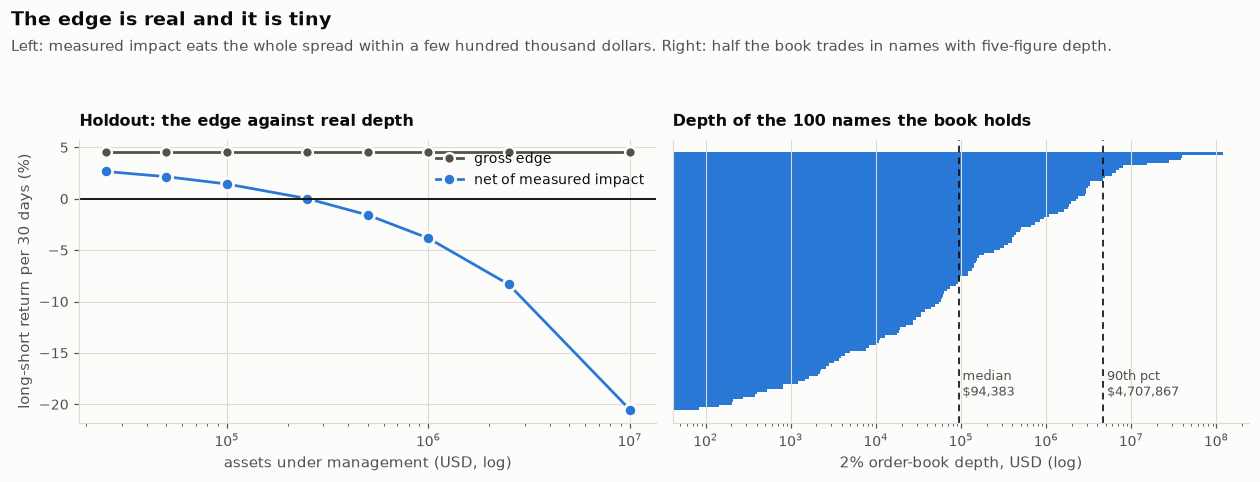

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
h = CAP[CAP.period == "holdout"]
axes[0].plot(h.AUM_usd, h["gross_%"], "o-", color=INK_2, ms=7, mec=SURFACE, mew=1.6,
             label="gross edge")
axes[0].plot(h.AUM_usd, h["net_%"], "o-", color=C1, ms=8, mec=SURFACE, mew=1.8,
             label="net of measured impact")
axes[0].axhline(0, color=INK, lw=1.2)
axes[0].set_xscale("log"); axes[0].set_xlabel("assets under management (USD, log)")
axes[0].set_ylabel("long-short return per 30 days (%)")
axes[0].set_title("Holdout: the edge against real depth")
axes[0].legend(loc="upper right"); axes[0].set_axisbelow(True)

d = ok.depth_2pct_usd.sort_values()
axes[1].barh(range(len(d)), d.values, color=C1, height=1.0)
axes[1].set_yticks([]); axes[1].set_xscale("log")
axes[1].set_xlabel("2% order-book depth, USD (log)")
axes[1].set_title(f"Depth of the {len(d)} names the book holds")
for pct, lbl in ((0.5, "median"), (0.9, "90th pct")):
    v = d.quantile(pct)
    axes[1].axvline(v, color=INK, lw=1.1, ls=(0, (4, 3)))
    axes[1].text(v * 1.1, len(d) * 0.05, f"{lbl}\n${v:,.0f}", fontsize=8.5, color=INK_2)
axes[1].grid(axis="y", visible=False)
figure_titles(fig, "The edge is real and it is tiny",
              "Left: measured impact eats the whole spread within a few hundred thousand dollars. Right: half the book trades in names with five-figure depth.")
plt.show()

## 7. The decisive test: edge versus tradability

The capacity numbers above answer "how much size fits". This asks the sharper
question: **as you restrict the book to progressively more liquid names, what
happens to the edge?**

Notebook 3 already showed the two endpoints — zero in perp-listed names,
present in non-perp names. This fills in the curve between them using measured
depth rather than the crude perp/no-perp split.

The result is not a smooth slide. The edge holds up — within noise, even
strengthens — as long as the depth requirement stays under about \$50k, and
then falls away to nothing between \$100k and \$250k. So the boundary is not
gradual: there is a band of genuinely illiquid names where the effect lives,
and it stops at roughly the point where a name becomes worth an arbitrageur's
attention.

One caveat, stated plainly: depth is a **current** snapshot applied across the
whole history, so a token's 2026 liquidity decides whether it was in the 2022
book. That is look-ahead. It biases the liquid bucket toward names that
survived and stayed liquid — i.e. it should, if anything, make the liquid
bucket look *better* than it was. A declining curve is therefore a conservative
result.

In [15]:
DEPTH_ALL = pd.Series(np.nan, index=PX.columns)
DEPTH_ALL.update(ok.depth_2pct_usd)

rows = []
for thr in (0, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000):
    keep = DEPTH_ALL[DEPTH_ALL >= thr].index if thr > 0 else DEPTH_ALL.dropna().index
    uni = UNSHORT.copy()
    uni[[c for c in uni.columns if c not in keep]] = False
    if uni.sum(axis=1).loc[BACKTEST_START:].mean() < 12:
        rows.append({"min_depth_usd": thr, "names": int(uni.sum(axis=1).loc[BACKTEST_START:].mean()),
                     "note": "too few names to sort"})
        continue
    r_all = run(SIGS["composite"], universe=uni, shortable=uni, end=None, cost_bps=0, n_q=4)
    r_hold = run(SIGS["composite"], universe=uni, shortable=uni,
                 start=DESIGN_END, end=None, cost_bps=0, n_q=4)
    rows.append({"min_depth_usd": thr,
                 "names": round(float(uni.sum(axis=1).loc[BACKTEST_START:].mean()), 1),
                 "gross_%_full": r_all["net_%"] if r_all else np.nan,
                 "t_full": r_all["t_net"] if r_all else np.nan,
                 "gross_%_holdout": r_hold["net_%"] if r_hold else np.nan,
                 "t_holdout": r_hold["t_net"] if r_hold else np.nan})
CURVE = pd.DataFrame(rows)
print("GROSS EDGE (before costs) BY MINIMUM DEPTH REQUIREMENT\n")
print(CURVE.round(2).to_string(index=False))
PERP_HOLDOUT_T = -0.19   # notebook 3, sorted within perp-listed names only
PERP_HOLDOUT_PCT = -0.26
print(f"""
  Costs are set to zero here on purpose. This is not about whether you can afford
  to trade the names - it is about whether the signal is even present in them.

  The curve runs out of names above a few hundred thousand dollars of depth,
  because the non-perp universe simply does not contain many liquid tokens. Its
  right-hand endpoint is already known from notebook 3: sorted within the
  perp-listed (most liquid) names, the same signal gives t = {PERP_HOLDOUT_T:+.2f} in the
  holdout. Quartiles are used instead of quintiles here to hold breadth as the
  screen tightens.""")

GROSS EDGE (before costs) BY MINIMUM DEPTH REQUIREMENT

 min_depth_usd  names  gross_%_full  t_full  gross_%_holdout  t_holdout                  note
             0 35.000         5.300   2.130            4.740      1.820                   NaN
         10000 27.900         4.110   1.170            6.350      2.110                   NaN
         25000 25.100        -1.090  -0.250            6.410      1.740                   NaN
         50000 21.800         1.390   0.270            5.280      1.310                   NaN
        100000 18.300        -2.150  -0.350            1.640      0.680                   NaN
        250000 13.600       -14.200  -1.480            0.110      0.040                   NaN
        500000 10.000           NaN     NaN              NaN        NaN too few names to sort

  Costs are set to zero here on purpose. This is not about whether you can afford
  to trade the names - it is about whether the signal is even present in them.

  The curve runs out of names

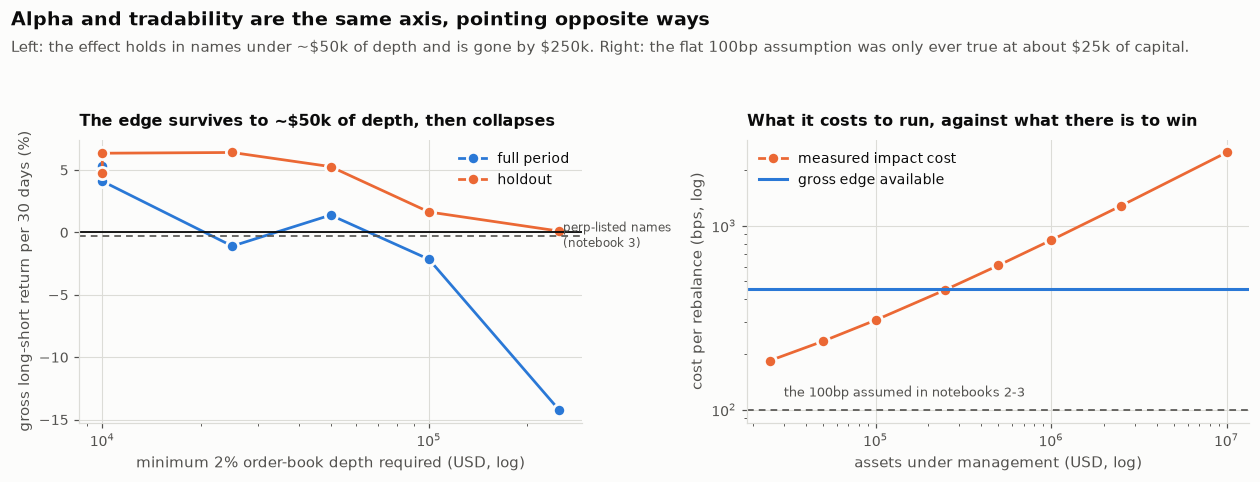

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
cv = CURVE.dropna(subset=["gross_%_full"])
axes[0].plot(cv.min_depth_usd.clip(lower=1e4), cv["gross_%_full"], "o-", color=C1,
             ms=8, mec=SURFACE, mew=1.8, label="full period")
axes[0].plot(cv.min_depth_usd.clip(lower=1e4), cv["gross_%_holdout"], "o-", color=C2,
             ms=8, mec=SURFACE, mew=1.8, label="holdout")
axes[0].axhline(0, color=INK, lw=1.2)
axes[0].set_xscale("log")
axes[0].set_xlabel("minimum 2% order-book depth required (USD, log)")
axes[0].set_ylabel("gross long-short return per 30 days (%)")
axes[0].set_title("The edge survives to ~$50k of depth, then collapses")
axes[0].axhline(PERP_HOLDOUT_PCT, color=INK_2, lw=1.1, ls=(0, (4, 3)))
axes[0].text(cv.min_depth_usd.clip(lower=1e4).max(), PERP_HOLDOUT_PCT,
             " perp-listed names\n (notebook 3)", fontsize=8, color=INK_2, va="center")
axes[0].legend(loc="upper right"); axes[0].set_axisbelow(True)

h2 = CAP[CAP.period == "holdout"]
axes[1].plot(h2.AUM_usd, h2.cost_bps, "o-", color=C2, ms=8, mec=SURFACE, mew=1.8,
             label="measured impact cost")
axes[1].axhline(h2["gross_%"].iloc[0] * 100, color=C1, lw=2.0, label="gross edge available")
axes[1].axhline(100, color=INK_2, lw=1.1, ls=(0, (4, 3)))
axes[1].text(3e4, 118, "the 100bp assumed in notebooks 2-3", fontsize=8.5, color=INK_2)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("assets under management (USD, log)")
axes[1].set_ylabel("cost per rebalance (bps, log)")
axes[1].set_title("What it costs to run, against what there is to win")
axes[1].legend(loc="upper left")
figure_titles(fig, "Alpha and tradability are the same axis, pointing opposite ways",
              "Left: the effect holds in names under ~$50k of depth and is gone by $250k. Right: the flat 100bp assumption was only ever true at about $25k of capital.")
plt.show()

---
# VERDICT

In [17]:
W_ = 80
h = CAP[CAP.period == "holdout"].set_index("AUM_usd")
pos = h[h["net_%"] > 0]
be = pos.index.max() if len(pos) else None
t_at = pos["t_net"].iloc[-1] if len(pos) else np.nan

print("=" * W_)
print("A REAL EFFECT WITH ROUGHLY NO CAPACITY".center(W_))
print("=" * W_)
print(f"""
THE COST ASSUMPTION WAS THE PROBLEM, AND FIXING IT ENDS THE INVESTIGATION
{'-'*W_}
  Notebooks 2 and 3 charged a flat 100bp round trip. Measured against real
  order-book depth, that is what this book costs at roughly
  ${np.interp(100, h['cost_bps'], h.index):,.0f} of AUM. Above that the cost model and the flat
  assumption diverge fast, because impact grows with the square root of size
  while the edge does not grow at all.

  holdout gross edge          {h['gross_%'].iloc[0]:+.2f}%/30d
  net at $50k                 {h.loc[50_000,'net_%']:+.2f}%/30d   (cost {h.loc[50_000,'cost_bps']:,.0f}bp, t={h.loc[50_000,'t_net']:.2f})
  net at $250k                {h.loc[250_000,'net_%']:+.2f}%/30d   (cost {h.loc[250_000,'cost_bps']:,.0f}bp, t={h.loc[250_000,'t_net']:.2f})
  net at $1M                  {h.loc[1_000_000,'net_%']:+.2f}%/30d   (cost {h.loc[1_000_000,'cost_bps']:,.0f}bp, t={h.loc[1_000_000,'t_net']:.2f})
  net at $10M                 {h.loc[10_000_000,'net_%']:+.2f}%/30d   (cost {h.loc[10_000_000,'cost_bps']:,.0f}bp)

WHY THE CAPACITY IS SO SMALL
{'-'*W_}
  The median name in this book has ${ok.depth_2pct_usd.median():,.0f} of depth within 2% of mid.
  The book runs ~{(W_ALL != 0).sum(axis=1).mean():.0f} positions, so at $1M of AUM each clip is around
  ${1_000_000/(W_ALL != 0).sum(axis=1).mean():,.0f} - a meaningful fraction of the entire visible book in that
  name. Reported volume flatters that badly: 2% depth is a median of only
  {wash.depth_per_vol.median()*100:.1f}% of the same venues' 24h volume, so sizing off volume rather than
  depth would have overstated capacity by one to two orders of magnitude.

  And the edge is confined to that band by construction. Require more than
  ~$50k of depth and it starts to fade; require $250k and it is gone (t={CURVE.set_index('min_depth_usd').loc[250_000,'t_holdout']:+.2f}),
  which is where it meets notebook 3's perp-listed result of {PERP_HOLDOUT_T:+.2f}.

  This is not a fixable execution problem. The alpha exists BECAUSE these names
  are too illiquid for anyone to arbitrage; the illiquidity is the source of the
  premium, not an obstacle in front of it. Any size large enough to matter is
  large enough to destroy it.
""")
print("=" * W_)
print("BOTTOM LINE")
print("=" * W_)
print(f"""  Four notebooks, and the answer is stable: NO.

  There IS a real signal - fee growth predicts crypto cross-sections - and it
  is economically coherent. It is a liquidity premium. It is zero in every
  name liquid enough to short, present only in names with five-figure order
  books, and priced away by its own market impact somewhere around
  {'$%s of AUM' % f'{be:,.0f}' if be else 'a sum too small to bother measuring'}.

  That is a real finding about how this market works. It is not a strategy,
  and no further backtesting on this data will make it one. If you want to
  pursue it, the honest framing is a personal-size book of a few hundred
  thousand dollars, not a fund - and at that size the return on your time is
  the thing to question, not the return on capital.""")
print("=" * W_)

                     A REAL EFFECT WITH ROUGHLY NO CAPACITY                     

THE COST ASSUMPTION WAS THE PROBLEM, AND FIXING IT ENDS THE INVESTIGATION
--------------------------------------------------------------------------------
  Notebooks 2 and 3 charged a flat 100bp round trip. Measured against real
  order-book depth, that is what this book costs at roughly
  $25,000 of AUM. Above that the cost model and the flat
  assumption diverge fast, because impact grows with the square root of size
  while the edge does not grow at all.

  holdout gross edge          +4.51%/30d
  net at $50k                 +2.16%/30d   (cost 236bp, t=1.10)
  net at $250k                +0.02%/30d   (cost 449bp, t=0.01)
  net at $1M                  -3.84%/30d   (cost 835bp, t=-1.76)
  net at $10M                 -20.53%/30d   (cost 2,504bp)

WHY THE CAPACITY IS SO SMALL
--------------------------------------------------------------------------------
  The median name in this book has $94,383 of dept